In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df= pd.read_csv('Data/Global_Smartwatch_Marketplace_Insights_2026.csv')

In [3]:
df.columns

Index(['brand', 'condition', 'Case_Size_mm', 'Country', 'price', 'Seller_ID',
       'Is_Worldwide_Shipping', 'title'],
      dtype='object')

In [4]:
df.shape

(3607, 8)

In [5]:
df.describe()

,Case_Size_mm,price,Is_Worldwide_Shipping
count,2729.000000,3607.000000,3607.000000
mean,45.942836,617.819739,0.273357
std,3.165700,1071.008291,0.445745
min,26.000000,120.000000,0.000000
25%,44.000000,458.745000,0.000000
50%,46.000000,550.000000,0.000000
75%,49.000000,699.000000,1.000000
max,52.000000,49900.000000,1.000000


In [6]:
df.head(10)

,brand,condition,Case_Size_mm,Country,price,Seller_ID,Is_Worldwide_Shipping,title
0,Garmin,Used,NaN,Japan,999.76,Seller_0001,1,Garmin fenix 7 Pro Sapphire Dual Power Watch 4...
1,Garmin,Used,NaN,Japan,928.00,Seller_0002,1,Garmin Descent Mk1 Dive Computer Smartwatch GP...
2,Garmin,Used,50.0,Japan,934.92,Seller_0001,1,Garmin Fenix 7X Pro Solar Sapphire 50mm GPS Mu...
3,Garmin,New,NaN,Canada,1200.00,Seller_0003,0,garmin tactix 7 amoled edition BNIB
4,Garmin,Used,43.0,Japan,962.08,Seller_0001,1,Garmin Descent MK2S GPS Watch 43mm Light Sand ...
5,Garmin,Used,NaN,Japan,902.28,Seller_0001,1,Garmin Descent Mk1 Dive Computer Smartwatch GP...
6,Garmin,Used,NaN,Japan,913.36,Seller_0001,1,Garmin Venu X1 Black Smartwatch GPS Multisport...
7,Garmin,Used,47.0,Japan,911.44,Seller_0001,1,Garmin Venu X1 AMOLED Sapphire Titanium 47mm G...
8,Garmin,Used,NaN,Japan,908.06,Seller_0001,1,Garmin Epix GPS Porsche Design Smartwatch
9,Garmin,Used,NaN,Japan,884.90,Seller_0001,1,Garmin Tacx FLUX S Smart Direct Drive Trainer ...


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3607 entries, 0 to 3606
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   brand                  3607 non-null   object 
 1   condition              3607 non-null   object 
 2   Case_Size_mm           2729 non-null   float64
 3   Country                3607 non-null   object 
 4   price                  3607 non-null   float64
 5   Seller_ID              3607 non-null   object 
 6   Is_Worldwide_Shipping  3607 non-null   int64  
 7   title                  3607 non-null   object 
dtypes: float64(2), int64(1), object(5)
memory usage: 225.6+ KB


## Missing value: Case_Size_mm


In [8]:
print(df.nunique())

brand                       5
condition                  14
Case_Size_mm               15
Country                    27
price                    1117
Seller_ID                1754
Is_Worldwide_Shipping       2
title                    3179
dtype: int64


## Cần chuyển sang dạng category: Brand, Condition, Country

In [9]:
convert_category= ['brand', 'condition', 'Country']
for col in convert_category:
    df[col]= df[col].astype('category')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3607 entries, 0 to 3606
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   brand                  3607 non-null   category
 1   condition              3607 non-null   category
 2   Case_Size_mm           2729 non-null   float64 
 3   Country                3607 non-null   category
 4   price                  3607 non-null   float64 
 5   Seller_ID              3607 non-null   object  
 6   Is_Worldwide_Shipping  3607 non-null   int64   
 7   title                  3607 non-null   object  
dtypes: category(3), float64(2), int64(1), object(2)
memory usage: 153.7+ KB


## Vẽ biểu đồ

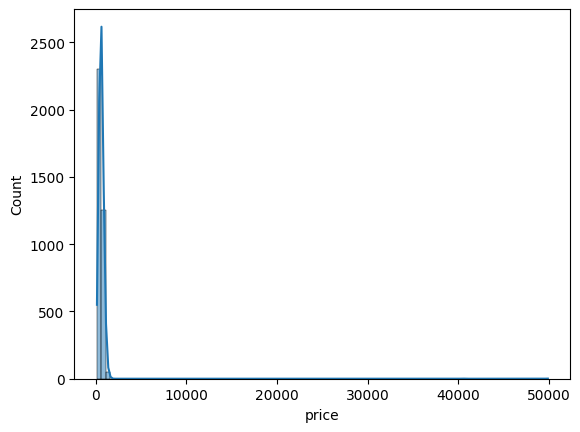

In [11]:
sns.histplot(data= df, x='price', bins=100, kde=True);

## Có giá trị ngoại lệ ở đây khi chủ yếu giá đồng hồ chỉ tập trung khoảng <5000 nhưng có những đồng hồ trị giá 50000

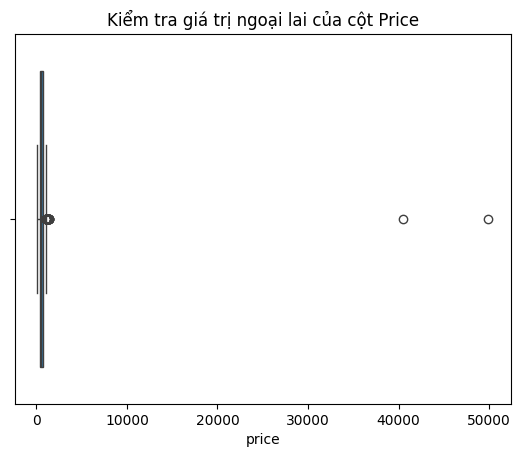

In [12]:
sns.boxplot(data=df, x='price')
plt.title('Kiểm tra giá trị ngoại lai của cột Price')
plt.show()

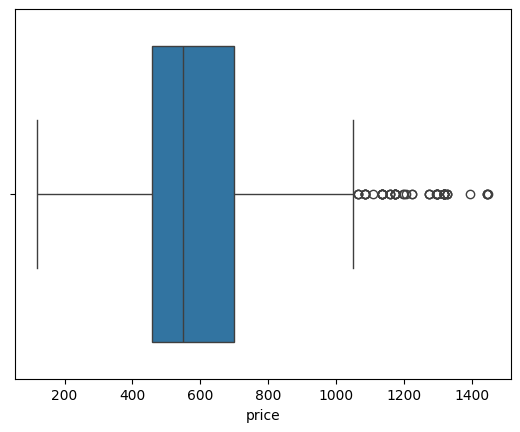

In [13]:
sns.boxplot(data=df[df['price'] < 2000], x='price');

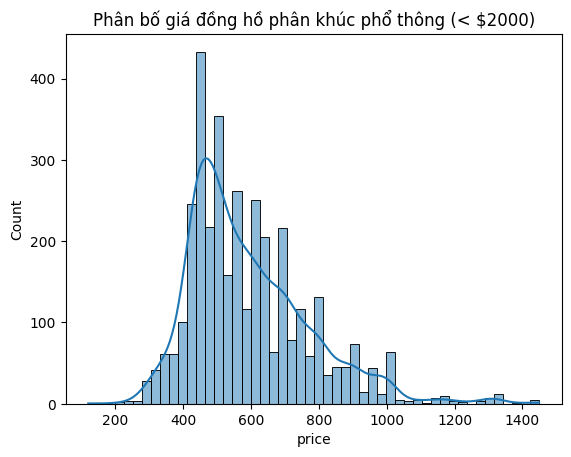

In [14]:
df_filtered = df[df['price'] < 2000]
sns.histplot(data=df_filtered, x='price', bins=50, kde=True)
plt.title('Phân bố giá đồng hồ phân khúc phổ thông (< $2000)')
plt.show()

## Ở đây cho thấy giá đồng hồ chủ yếu phân bố khoảng 420$-700$

In [15]:
df_filtered.value_counts()

brand   condition                Case_Size_mm  Country        price   Seller_ID    Is_Worldwide_Shipping  title                                                                           
Apple   Excellent - Refurbished  49.0          United States  839.95  Seller_0033  0                      Apple Watch Ultra 2 [GPS + Cellular 49mm] Smartwatch with Rugged Titanium Case &    6
Garmin  New                      41.0          United States  560.99  Seller_0033  0                      Garmin Venu 4, 41mm, Advanced Health and Fitness GPS Smartwatch, Bright and         5
Apple   Open box                 49.0          United States  450.00  Seller_1270  0                      Apple Watch Ultra 2 49mm Titanium, GPS + Cellular (Open Box)                        4
Garmin  New                      45.0          United States  560.99  Seller_0033  0                      Garmin Venu 4, 45mm, Advanced Health and Fitness GPS Smartwatch, Bright and         4
Apple   New                      49.0        

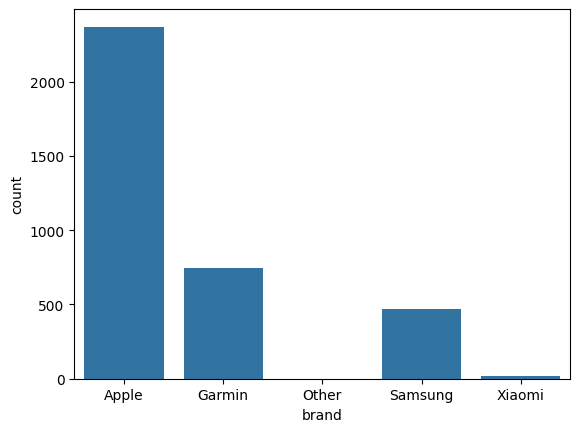

In [16]:
sns.countplot(data=df, x='brand');

In [17]:
df['brand'].unique()

['Garmin', 'Apple', 'Samsung', 'Xiaomi', 'Other']
Categories (5, object): ['Apple', 'Garmin', 'Other', 'Samsung', 'Xiaomi']

In [18]:
brand_counts = df['brand'].value_counts(normalize=True) * 100
print(brand_counts)

brand
Apple      65.705572
Garmin     20.682007
Samsung    13.030219
Xiaomi      0.554477
Other       0.027724
Name: proportion, dtype: float64


## Từ đây cho thấy Apple chiếm tỉ lệ rất cao khi đến tận 65.7% trong kho Xiaomi hay Other chỉ <1%

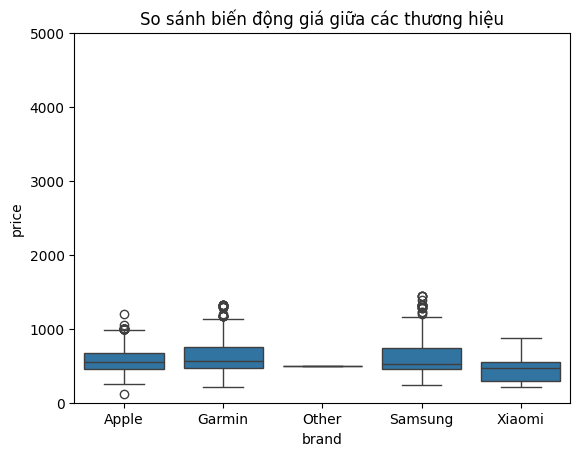

In [19]:
#plt.figure(figsize=(10, 6))
sns.boxplot(x='brand', y='price', data=df);
plt.title('So sánh biến động giá giữa các thương hiệu')
plt.ylim(0, 5000)
plt.show()

## Gộp Xiaomi vào Other do cả 2 tỉ lệ % quá thấp

In [20]:
df['brand'] = df['brand'].astype(str)
df['brand'] = df['brand'].replace(['Xiaomi', 'Other brand', 'Other'], 'Small brand')
df['brand'] = df['brand'].astype('category')
print(df['brand'].value_counts())

brand
Apple          2370
Garmin          746
Samsung         470
Small brand      21
Name: count, dtype: int64


In [21]:
df[df['price'] > 10000]

,brand,condition,Case_Size_mm,Country,price,Seller_ID,Is_Worldwide_Shipping,title
1662,Apple,Usado,49.0,Estados Unidos,40500.0,Seller_0751,0,"Apple Watch Ultra 2 49mm Titânio, Azul/Preto, ..."
2524,Samsung,Novo,47.0,Estados Unidos,49900.0,Seller_1215,0,Smartwatch (2025) SAMSUNG Galaxy Watch Ultra 4...


In [22]:
print(df['condition'].value_counts())

condition
New                         1553
Used                        1250
Open box                     581
Excellent - Refurbished      118
Very Good - Refurbished       40
For parts or not working      21
Good - Refurbished            20
New other                      5
Nuevo                          5
Usado                          5
Certified - Refurbished        4
Caja abierta                   3
--                             1
Novo                           1
Name: count, dtype: int64


## Ở condition có nhiều loại ngôn ngữ khác nhau, chưa kể phần Refurbished lại bị chia nhỏ quá mức

In [23]:
df['condition']=df['condition'].astype(str)
condition_map={
    'New': 'New', 'Nuevo': 'New', 'Novo': 'New', 'New other': 'New',
    'Used': 'Used', 'Usado': 'Used',
    'Open box': 'Open Box', 'Caja abierta': 'Open Box',
    'Excellent - Refurbished': 'Refurbished',
    'Very Good - Refurbished': 'Refurbished',
    'Good - Refurbished': 'Refurbished',
    'Certified - Refurbished': 'Refurbished',
    'For parts or not working': 'Broken/Other',
    '--': 'Broken/Other'
    }
df['condition']=df['condition'].replace(condition_map)
df['condition']=df['condition'].astype('category')  
df['condition'].value_counts()

condition
New             1564
Used            1255
Open Box         584
Refurbished      182
Broken/Other      22
Name: count, dtype: int64

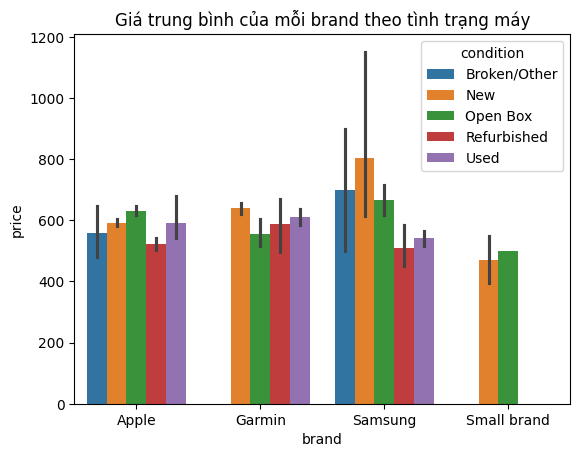

In [24]:
sns.barplot(data=df, x='brand', y='price', hue='condition')
plt.title('Giá trung bình của mỗi brand theo tình trạng máy')
plt.show()

## Từ biểu đồ cho thấy Apple giữ giá khá tốt khi mức giá chênh lệch giữa New hay Used là tương đối thấp

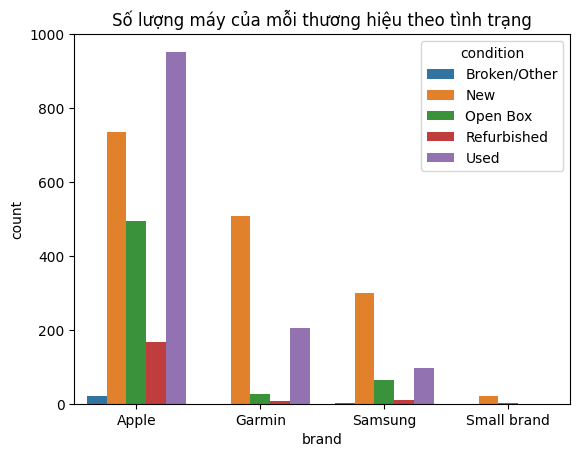

In [25]:
sns.countplot(data=df, x='brand', hue='condition');
plt.title('Số lượng máy của mỗi thương hiệu theo tình trạng');

In [26]:
df.groupby(['brand', 'condition'])['price'].describe()

/var/folders/z7/rzx5mnrn2l7fw6scbxh1jxc40000gn/T/ipykernel_36334/3638842253.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['brand', 'condition'])['price'].describe()


count        mean          std     min       25%  \
brand       condition                                                        
Apple       Broken/Other   20.0  558.161000   184.296384  314.99  429.0000   
            New           737.0  592.473202   148.591682  274.95  468.0000   
            Open Box      494.0  632.071437   168.162108  299.99  499.2475   
            Refurbished   166.0  523.442169   135.905699  120.00  429.0000   
            Used          953.0  589.865551  1301.669013  249.99  450.0000   
Garmin      New           508.0  638.868583   206.930061  215.10  479.6800   
            Open Box       26.0  556.780000   117.995818  425.00  495.6225   
            Refurbished     7.0  588.268571   125.550269  419.00  494.9950   
            Used          205.0  611.623024   182.519542  280.00  445.0000   
Samsung     Broken/Other    2.0  700.000000   282.842712  500.00  600.0000   
            New           299.0  804.680468  2861.952734  244.99  443.5600   
            Open Box       63.0  665.266825   202.194857  309.99  489.9950   
            Refurbished     9.0  511.101111   105.409257  399.99  450.0000   
            Used           97.0  540.931443   118.788378  350.00  450.0000   
Small brand New            20.0  468.981500   178.540613  213.53  290.9350   
            Open Box        1.0  499.990000          NaN  499.99  499.9900   

                              50%       75%       max  
brand       condition                                  
Apple       Broken/Other  509.970  619.9900    999.99  
            New           589.980  700.0000   1000.00  
            Open Box      609.475  722.2500   1199.00  
            Refurbished   489.990  627.9875    896.99  
            Used          503.340  600.0000  40500.00  
Garmin      New           567.450  749.9900   1319.00  
            Open Box      500.000  599.9975    900.00  
            Refurbished   579.990  704.4750    719.95  
            Used          577.960  780.3800    999.76  
Samsung     Broken/Other  700.000  800.0000    900.00  
            New           525.000  771.5600  49900.00  
            Open Box      675.000  799.0000   1000.00  
            Refurbished   450.000  649.9900    649.99  
            Used          517.500  597.9100    968.39  
Small brand New           463.990  545.0000    875.00  
            Open Box      499.990  499.9900    499.99

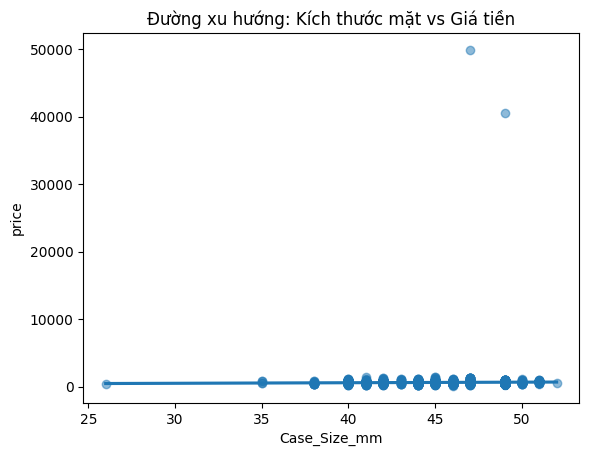

In [27]:
sns.regplot(data=df, x='Case_Size_mm', y='price', scatter_kws={'alpha':0.5})
plt.title('Đường xu hướng: Kích thước mặt vs Giá tiền')
plt.show()

## Ở đây cho thấy sơ bộ về sự tương quan giữa kích thước và giá tiền

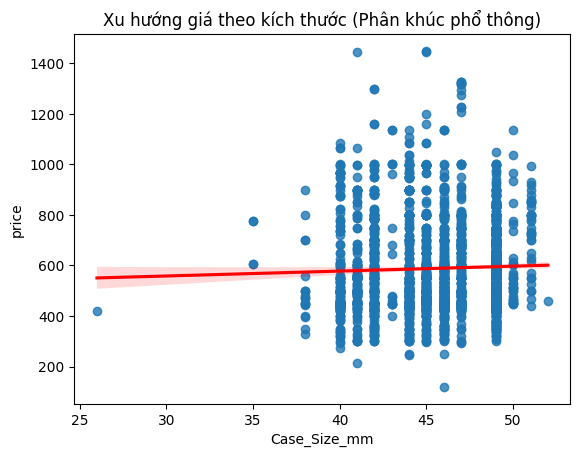

In [28]:
df_zoom = df[df['price'] < 5000]
sns.regplot(data=df_zoom, x='Case_Size_mm', y='price', line_kws={"color": "red"})
plt.title('Xu hướng giá theo kích thước (Phân khúc phổ thông)');

## Sau khi xem xét ở phân khúc phổ thông. Ta chứng minh được rằng sự tương quan giữa kích thước và giá tiền là rất thấp vì vậy giá tiền không phụ thuộc vào kích thước